In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [17]:
from sklearn.datasets import load_wine

In [18]:
#imports 

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
sns.set_style("whitegrid")

## 1. DATA ACQUISITION


In [19]:
# directly uploading the wine dataset from the sklearn.dataset 
# and understanding the shape values columns and rows and which is usefull info 
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
true_labels = data.target 

In [20]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [21]:
#checking the size of the data set 
print("Shape:", df.shape)

Shape: (178, 13)


In [22]:
#for checking  null values are present in the dataset 
print(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64


## 2. Exploratory data analysis 

In [51]:
# here i checked the mean, min,max std and count of all the columns 
# and how are they correlateed with each other  


print(df.describe().T)

                              count        mean         std     min       25%  \
alcohol                       178.0   13.000618    0.811827   11.03   12.3625   
malic_acid                    178.0    2.336348    1.117146    0.74    1.6025   
ash                           178.0    2.366517    0.274344    1.36    2.2100   
alcalinity_of_ash             178.0   19.494944    3.339564   10.60   17.2000   
magnesium                     178.0   99.741573   14.282484   70.00   88.0000   
total_phenols                 178.0    2.295112    0.625851    0.98    1.7425   
flavanoids                    178.0    2.029270    0.998859    0.34    1.2050   
nonflavanoid_phenols          178.0    0.361854    0.124453    0.13    0.2700   
proanthocyanins               178.0    1.590899    0.572359    0.41    1.2500   
color_intensity               178.0    5.058090    2.318286    1.28    3.2200   
hue                           178.0    0.957449    0.228572    0.48    0.7825   
od280/od315_of_diluted_wines

In [24]:
print(df.corr().T)

                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   

                              alcalinity_of_ash  magnesium  total_phenols  \
alcohol                   

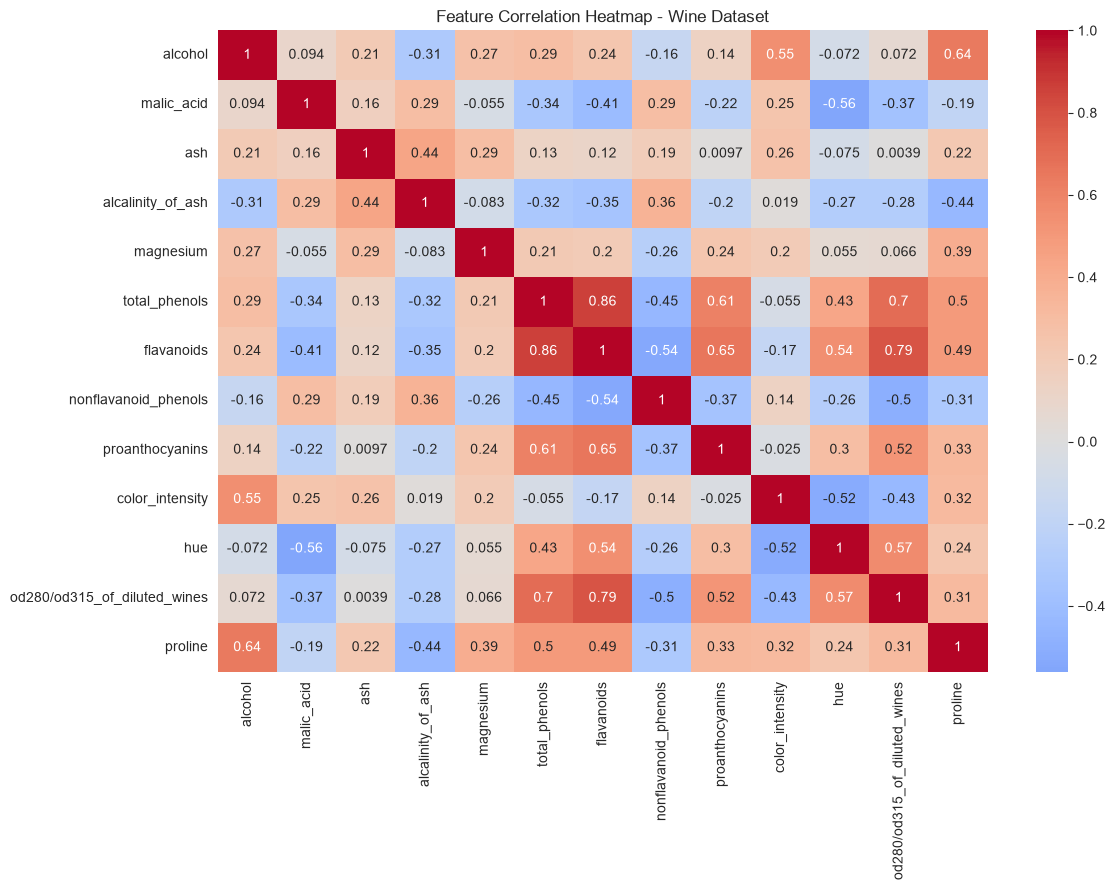

In [25]:
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True)
plt.title("Feature Correlation Heatmap - Wine Dataset")
plt.tight_layout()
plt.show()

## 3. PREPROCESSING


In [52]:
#scaling the range  
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


## 4. FINDING OPTIMAL K -> ELBOW METHOD + SILHOUETTE SCORE


In [53]:
#we dont need to randomly gyess the number of the cluster 
# so i used ekbow method and silhoueette score to calculate the vlaue of k accurattley 
wcss = []
sil_scores = []
K_range = range(2, 11)

In [28]:
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))



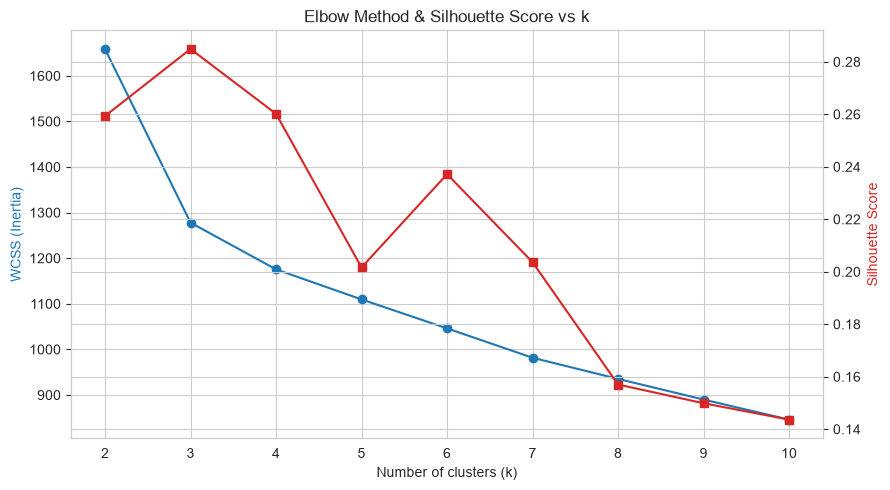

In [33]:
#ploting wscc values against k as blue line with circular markers at each point 
#ploting silhouette scores as red line on the same axis 

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(list(K_range), wcss, marker="o", color="tab:blue")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("WCSS (Inertia)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(list(K_range), sil_scores, marker="s", color="tab:red")
ax2.set_ylabel("Silhouette Score", color="tab:red")
plt.title("Elbow Method & Silhouette Score vs k")
plt.tight_layout()
plt.show()

In [34]:
#finding the best K-value from the k range  
best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)

Best k by silhouette: 3


## 5. K-MEANS CLUSTERING (final model)

In [40]:
#we find k = 3 her i had cluter all 178 wins into the 3 different clusters 

kmeans.fit_predict(X_scaled)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [39]:
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print("K-Means silhouette:",(kmeans_sil))

K-Means silhouette: 0.2848589191898987


## 6. HIERARCHICAL CLUSTERING + DENDROGRAM


In [54]:
# for cross checking with the hierarchical clustering and dendogram 
Z = linkage(X_scaled, method="ward")

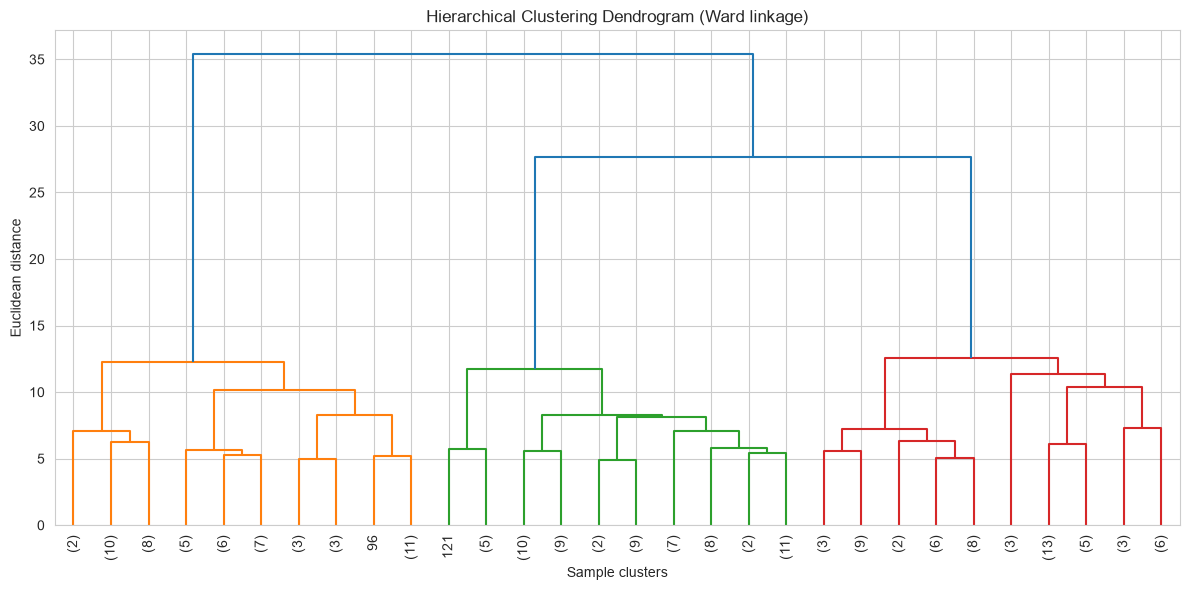

In [55]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage)")
plt.xlabel("Sample clusters")
plt.ylabel("Euclidean distance")
plt.tight_layout()
plt.show()

In [56]:
agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agglo_labels = agglo.fit_predict(X_scaled)
agglo_sil = silhouette_score(X_scaled, agglo_labels)
print("Agglomerative silhouette:", agglo_sil)

Agglomerative silhouette: 0.2774439826952265


## 7. PCA FOR 2D VISUALIZATION OF CLUSTERS

In [46]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance by 2 PCs:", pca.explained_variance_ratio_.sum())

Explained variance by 2 PCs: 0.5540633835693527


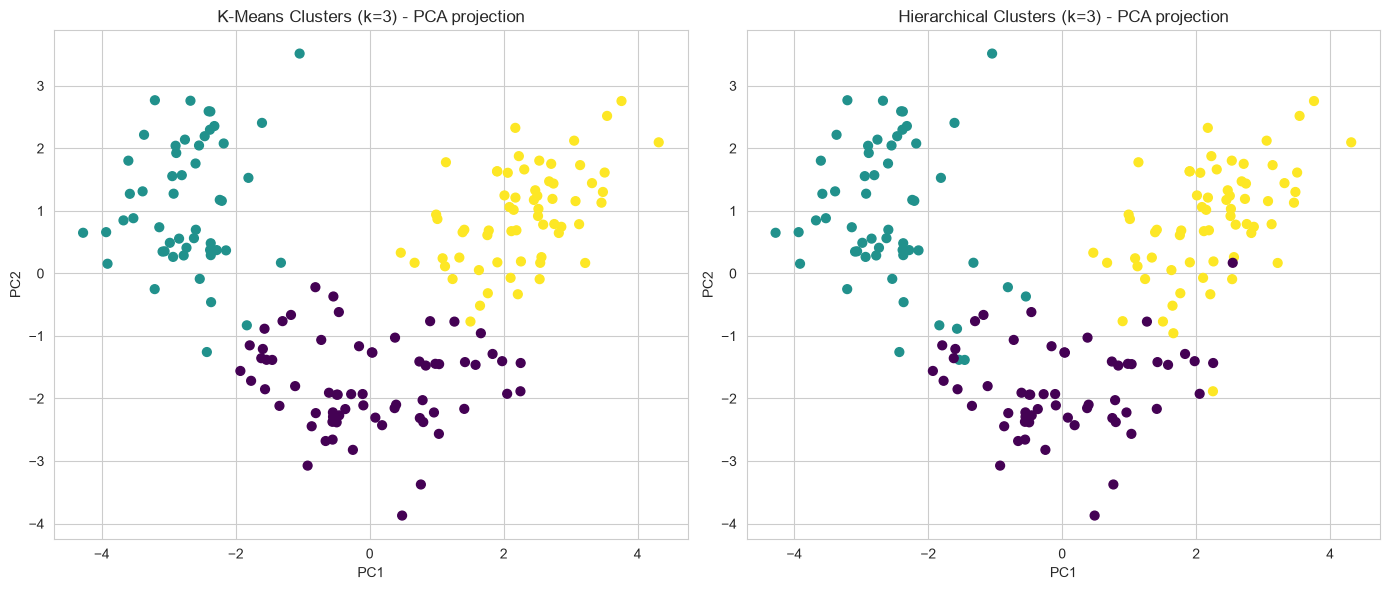

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis", s=40)
axes[0].set_title(f"K-Means Clusters (k={best_k}) - PCA projection")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=agglo_labels, cmap="viridis", s=40)
axes[1].set_title(f"Hierarchical Clusters (k={best_k}) - PCA projection")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()

## 8. CLUSTER PROFILING (what does each cluster mean?)


In [57]:
# this is to understand how the each cluster is different from other cluster 
df_profiled = df.copy()
df_profiled["KMeans_Cluster"] = kmeans_labels
profile = df_profiled.groupby("KMeans_Cluster").mean().round(2)
print(profile)
profile.to_csv("cluster_profile.csv")

                alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
KMeans_Cluster                                                            
0                 12.25        1.90  2.23              20.06      92.74   
1                 13.13        3.31  2.42              21.24      98.67   
2                 13.68        2.00  2.47              17.46     107.97   

                total_phenols  flavanoids  nonflavanoid_phenols  \
KMeans_Cluster                                                    
0                        2.25        2.05                  0.36   
1                        1.68        0.82                  0.45   
2                        2.85        3.00                  0.29   

                proanthocyanins  color_intensity   hue  \
KMeans_Cluster                                           
0                          1.62             2.97  1.06   
1                          1.15             7.23  0.69   
2                          1.92             5.45  1.07  